CDC Diabetes Health Indicators

[Dataset](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators)

In [5]:
!pip install ucimlrepo
!pip install imblearn
!pip install xgboost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df= pd.concat([X, y], axis=1)

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [8]:
# Descriptive Statistics
print(df.head())

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  NoDocbcCost  GenHlth  MentHlth  \
0             0       0        1  ...            0        5        18   
1             1       0        0  ...            1        3         0   
2             0       1        0  ...            1        5        30   
3             1       1        1  ...            0        2         0   
4             1       1        1  ...            0        2         3   

   PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary  
0        15         1    0  

In [9]:
df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


**Data Summary**

Based on the descriptive statistics of dataset, below are findings.

*   There are 253680 rows in dataset.
*   Dataset seems to be highly imbalanced based on mean of Diabetes_binary feature which is 0.13.




Data Pre-processing / Cleaning

In [10]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64


There are no missing values in database.

**Check for duplicates**

In [11]:

# Check for duplicates
duplicates_before_removal = df.duplicated()
print("Number of duplicate rows:", duplicates_before_removal.sum())
print("Number of rows before duplicate removal:", len(df))

Number of duplicate rows: 24206
Number of rows before duplicate removal: 253680


**Remove Duplicates**

In [12]:
# emove duplicates
df = df.drop_duplicates()
#print rows after removal of duplicates
print("Number of rows after removing duplicates:", len(df))

Number of rows after removing duplicates: 229474



**Perform exploratory data analysis and multivariate analysis on the dataset.**

## Visualize the frequency distribution of key features using histograms and box plots


Use histograms and box plots to understand the distribution of numerical features and count plots for categorical features.


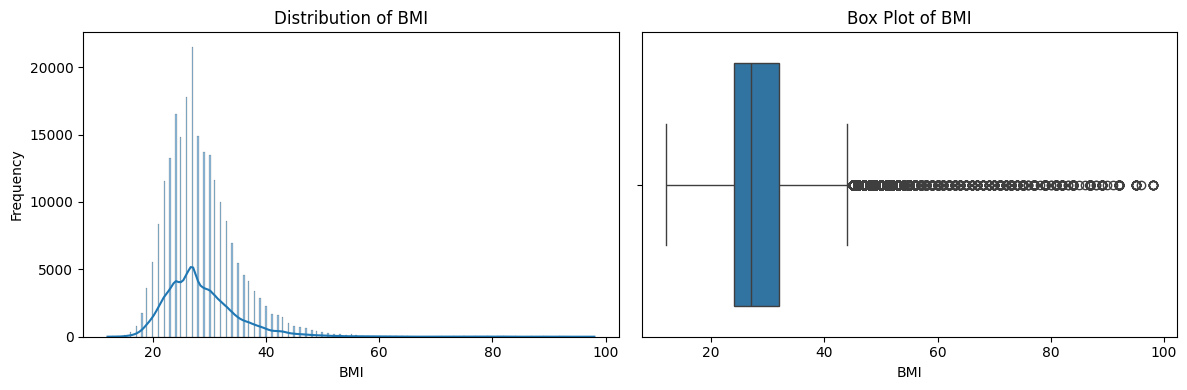

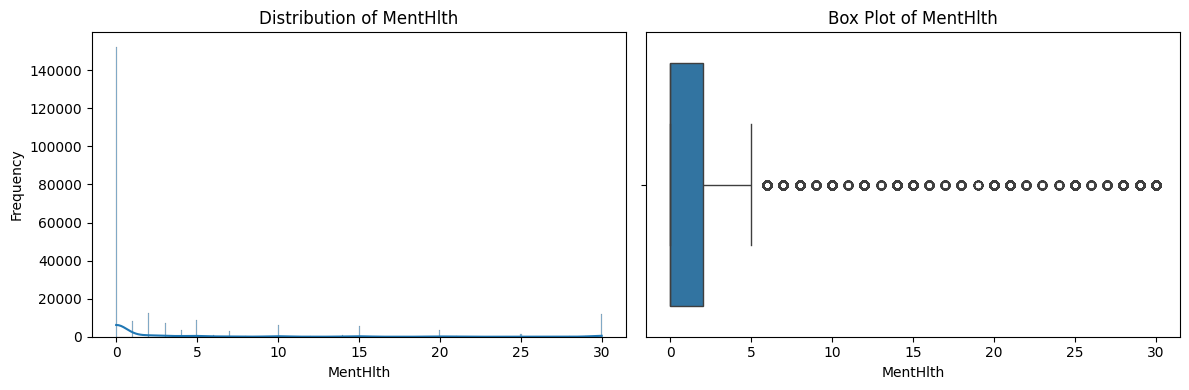

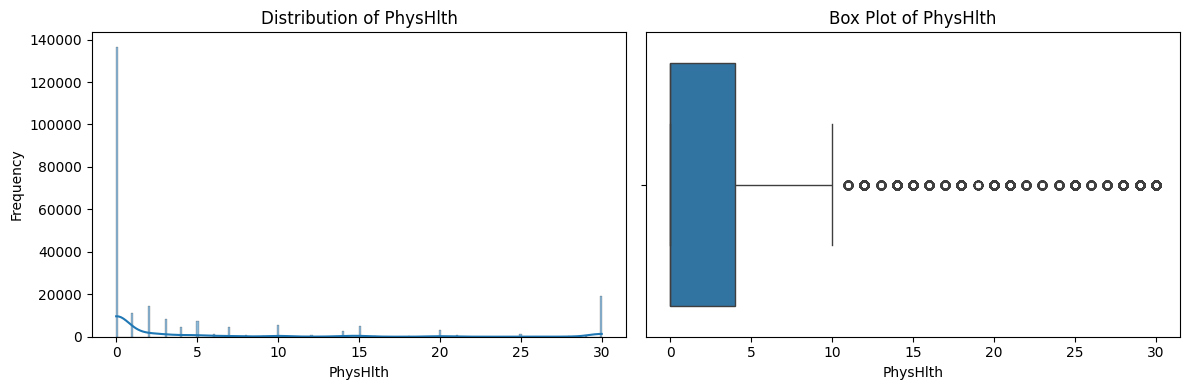

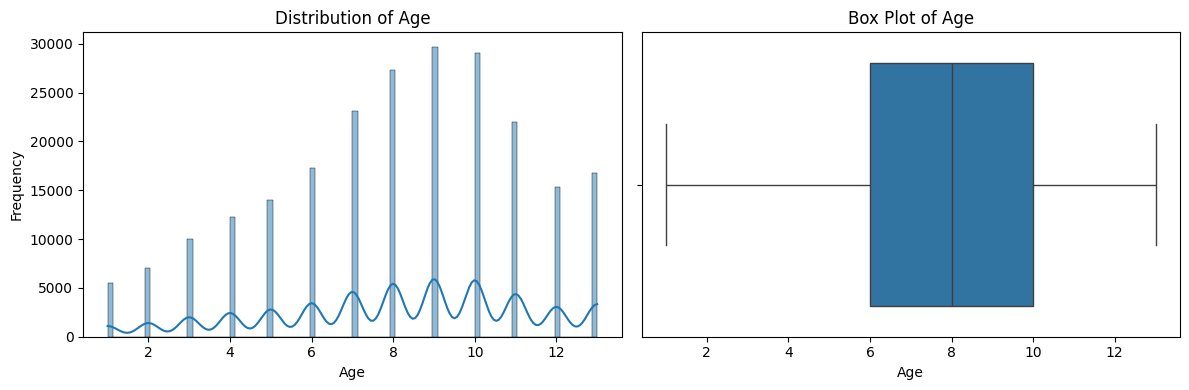

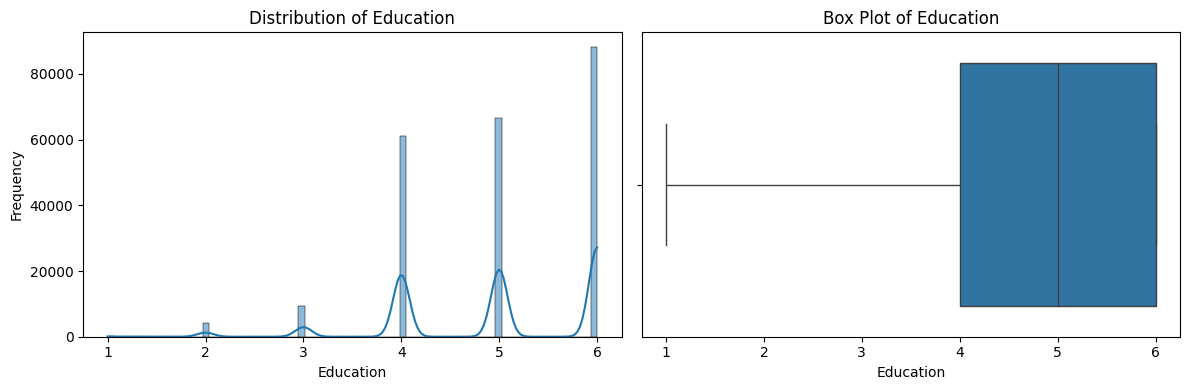

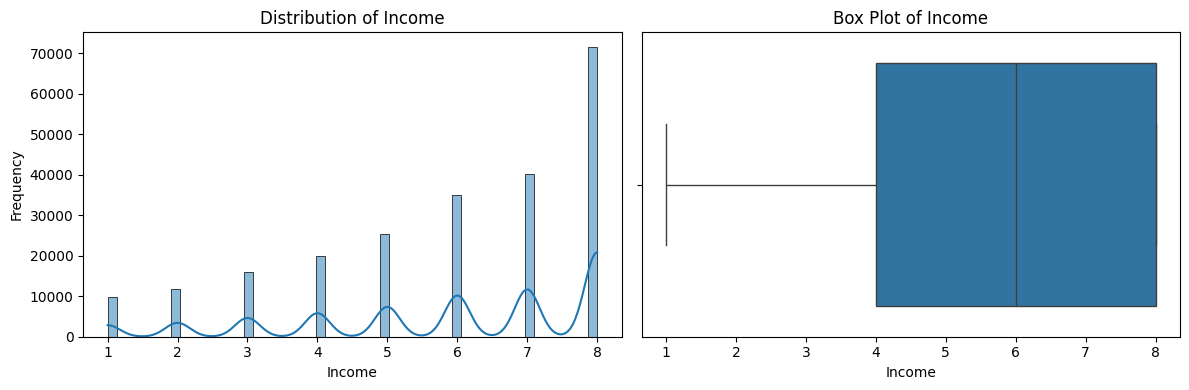

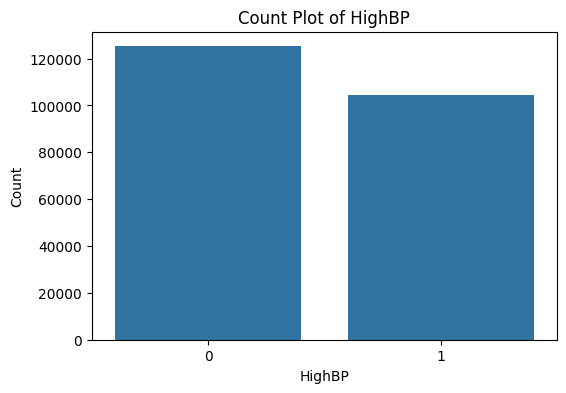

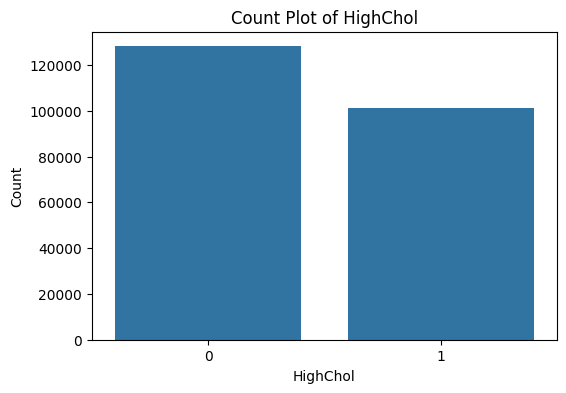

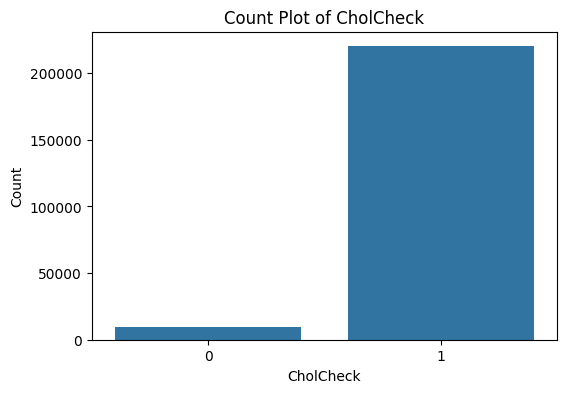

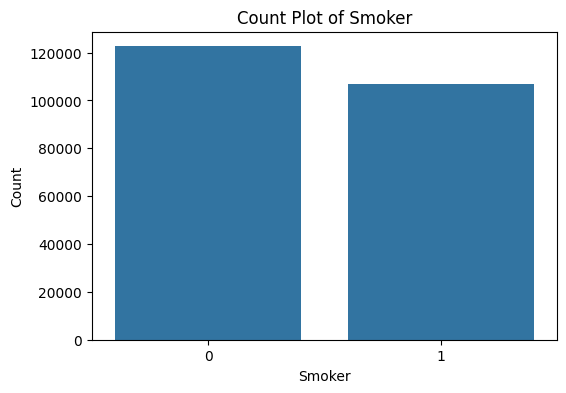

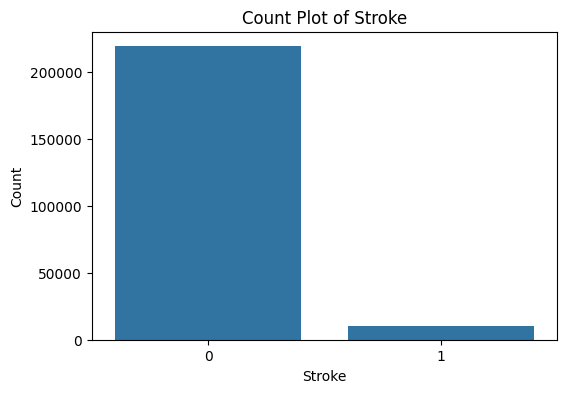

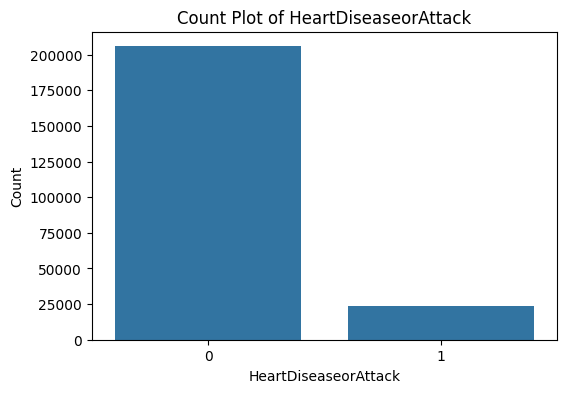

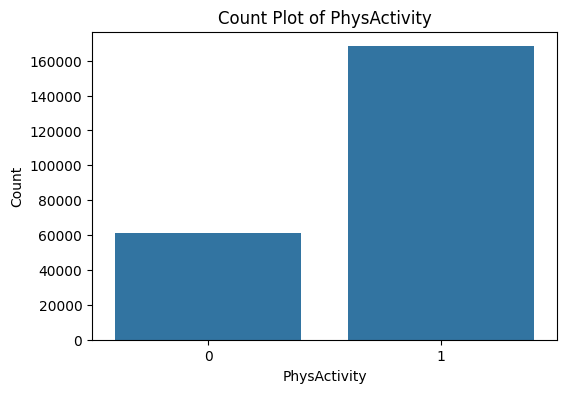

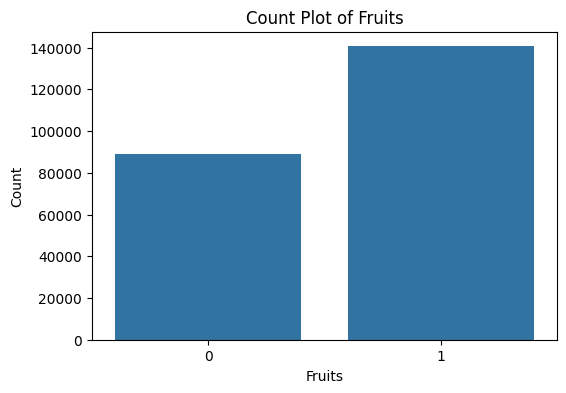

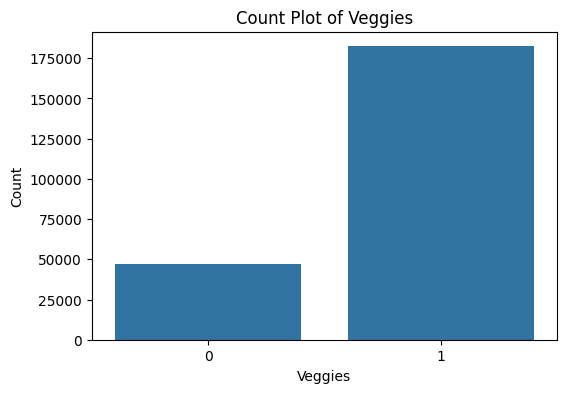

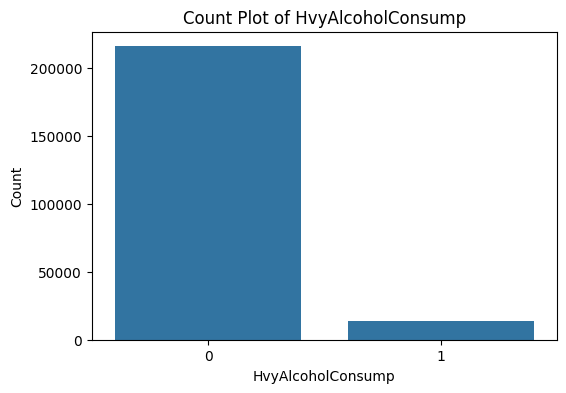

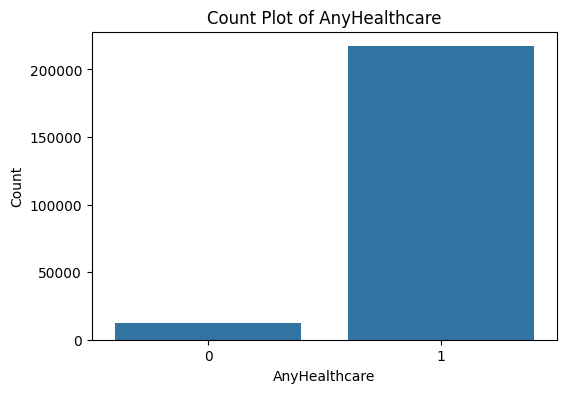

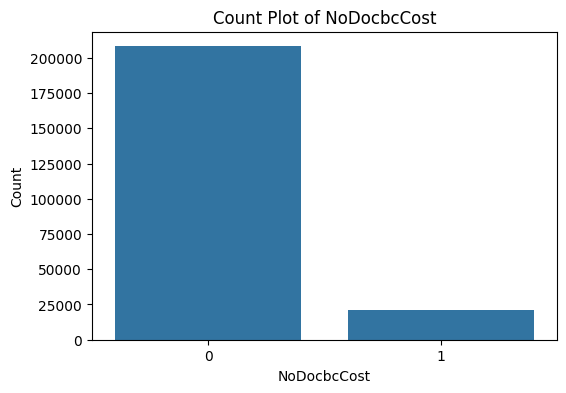

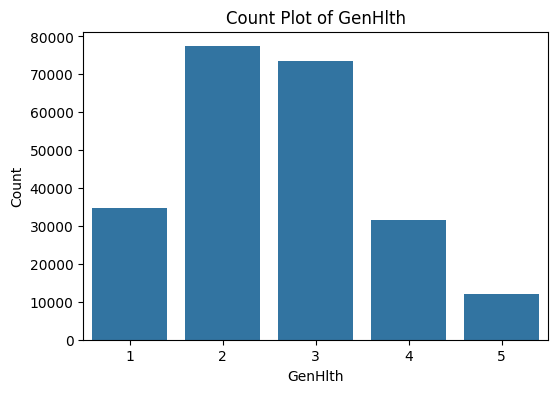

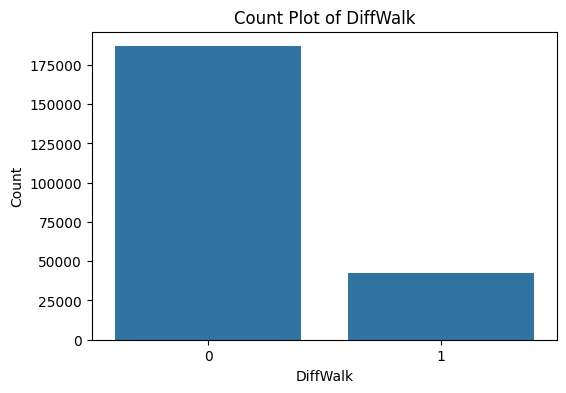

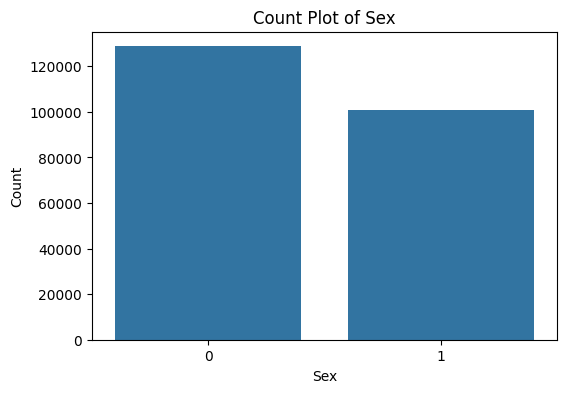

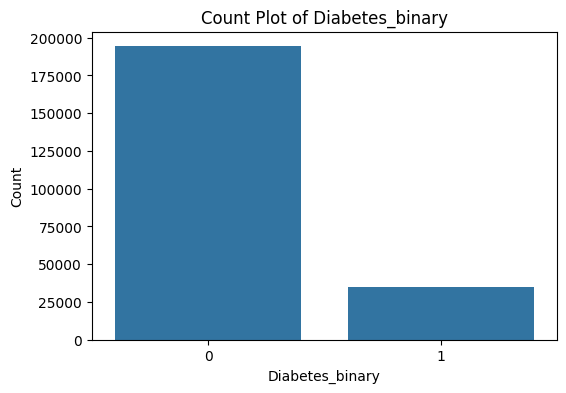

In [13]:
#exploratory data analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                     'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                     'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex','Diabetes_binary']

# Histograms and Box plots for numerical columns side by side
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # Reduced size and side by side
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    sns.boxplot(data=df, x=col, ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

# Count plots for categorical columns with reduced size
for col in categorical_cols:
    plt.figure(figsize=(6, 4)) # Reduced size
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## Correlation analysis between features

Use scatter plots, heatmaps, and pair plots to explore correlations and relationships between different variables.


**Reasoning**:
 Correlation matrix for the numerical columns and then generate a heatmap to visualize the correlations. And then generate pair plots for a subset of numerical columns to explore pairwise relationships.



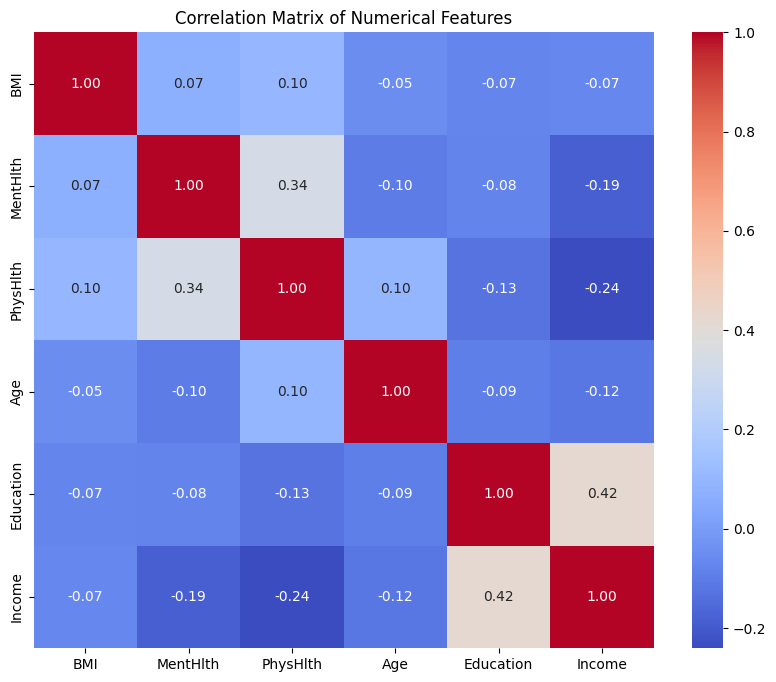

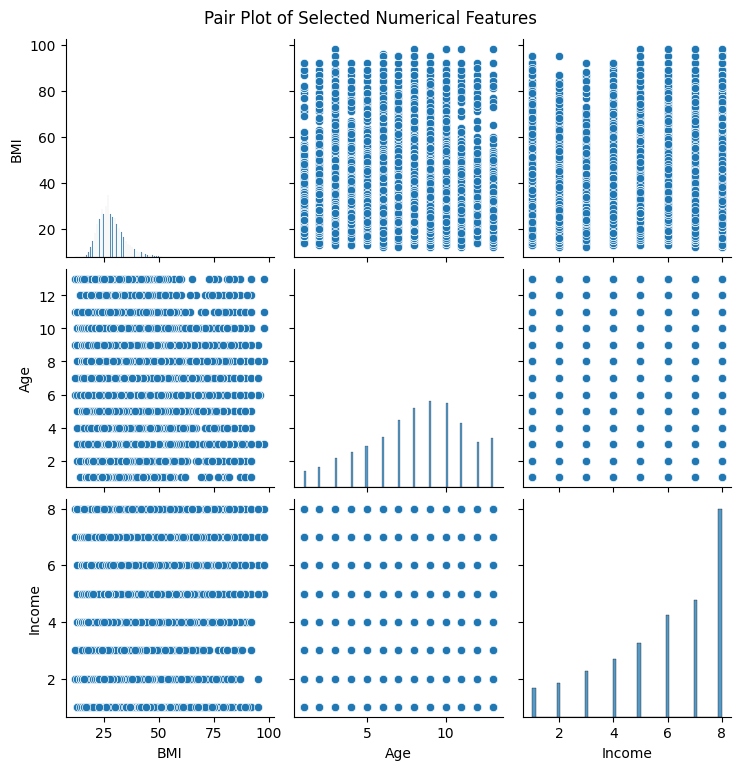

In [14]:
# Create a correlation matrix of the numerical columns
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
correlation_matrix = df[numerical_cols].corr()

# Generate a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Generate pair plots for a subset of numerical columns to visualize pairwise relationships
subset_numerical_cols = ['BMI', 'Age', 'Income'] # Selecting a smaller subset for clarity
sns.pairplot(df[subset_numerical_cols])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

Correlation with Diabetes_binary:
Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


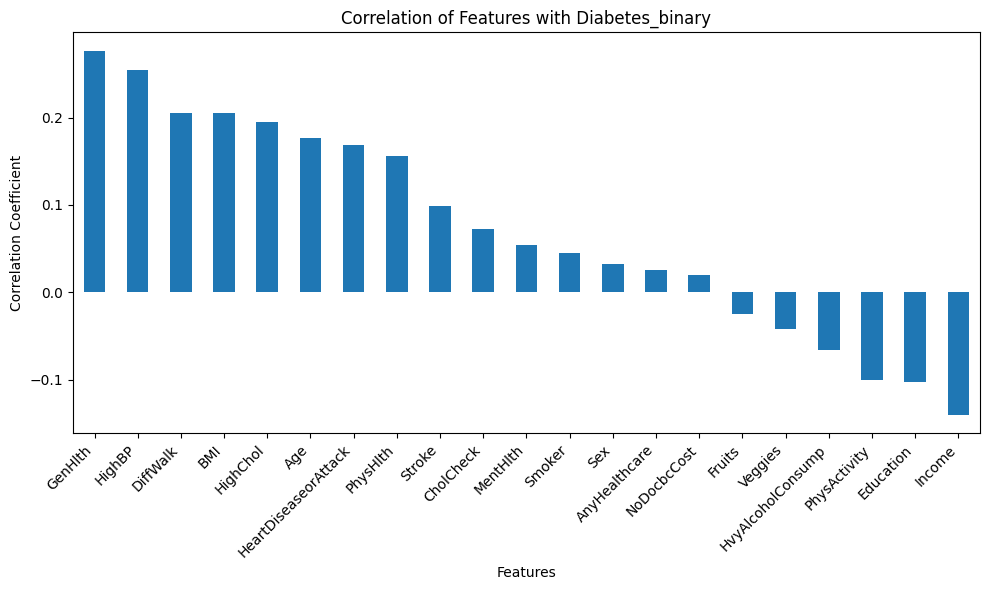

In [15]:
# Calculate the correlation matrix for the combined dataframe
correlation_matrix_combined = df.corr()

# Get the correlations with the 'Diabetes_binary' column
correlation_with_diabetes = correlation_matrix_combined['Diabetes_binary'].sort_values(ascending=False)

# Display the correlations
print("Correlation with Diabetes_binary:")
print(correlation_with_diabetes)

# Optional: Visualize the correlations with a bar plot
plt.figure(figsize=(10, 6))
correlation_with_diabetes.drop('Diabetes_binary').plot(kind='bar') # Drop the self-correlation
plt.title('Correlation of Features with Diabetes_binary')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analyze the relationship between features and the target variable
Visualize the distribution of features for each class in the target variable to understand how features differ between diabetic and non-diabetic individuals.


**Reasoning**:
Combine the features and target into a single dataframe and then visualize the distribution of features for each target class.



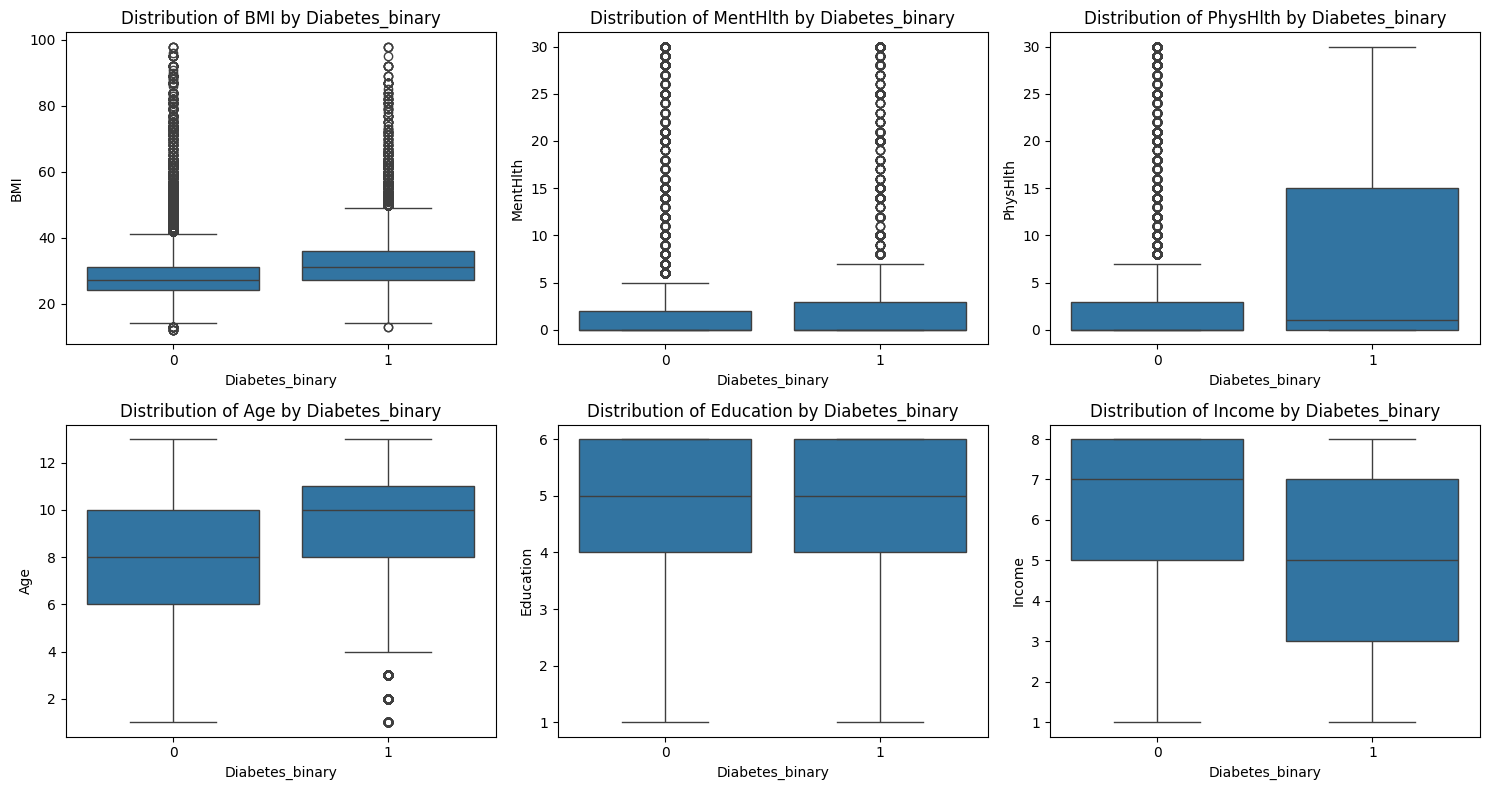

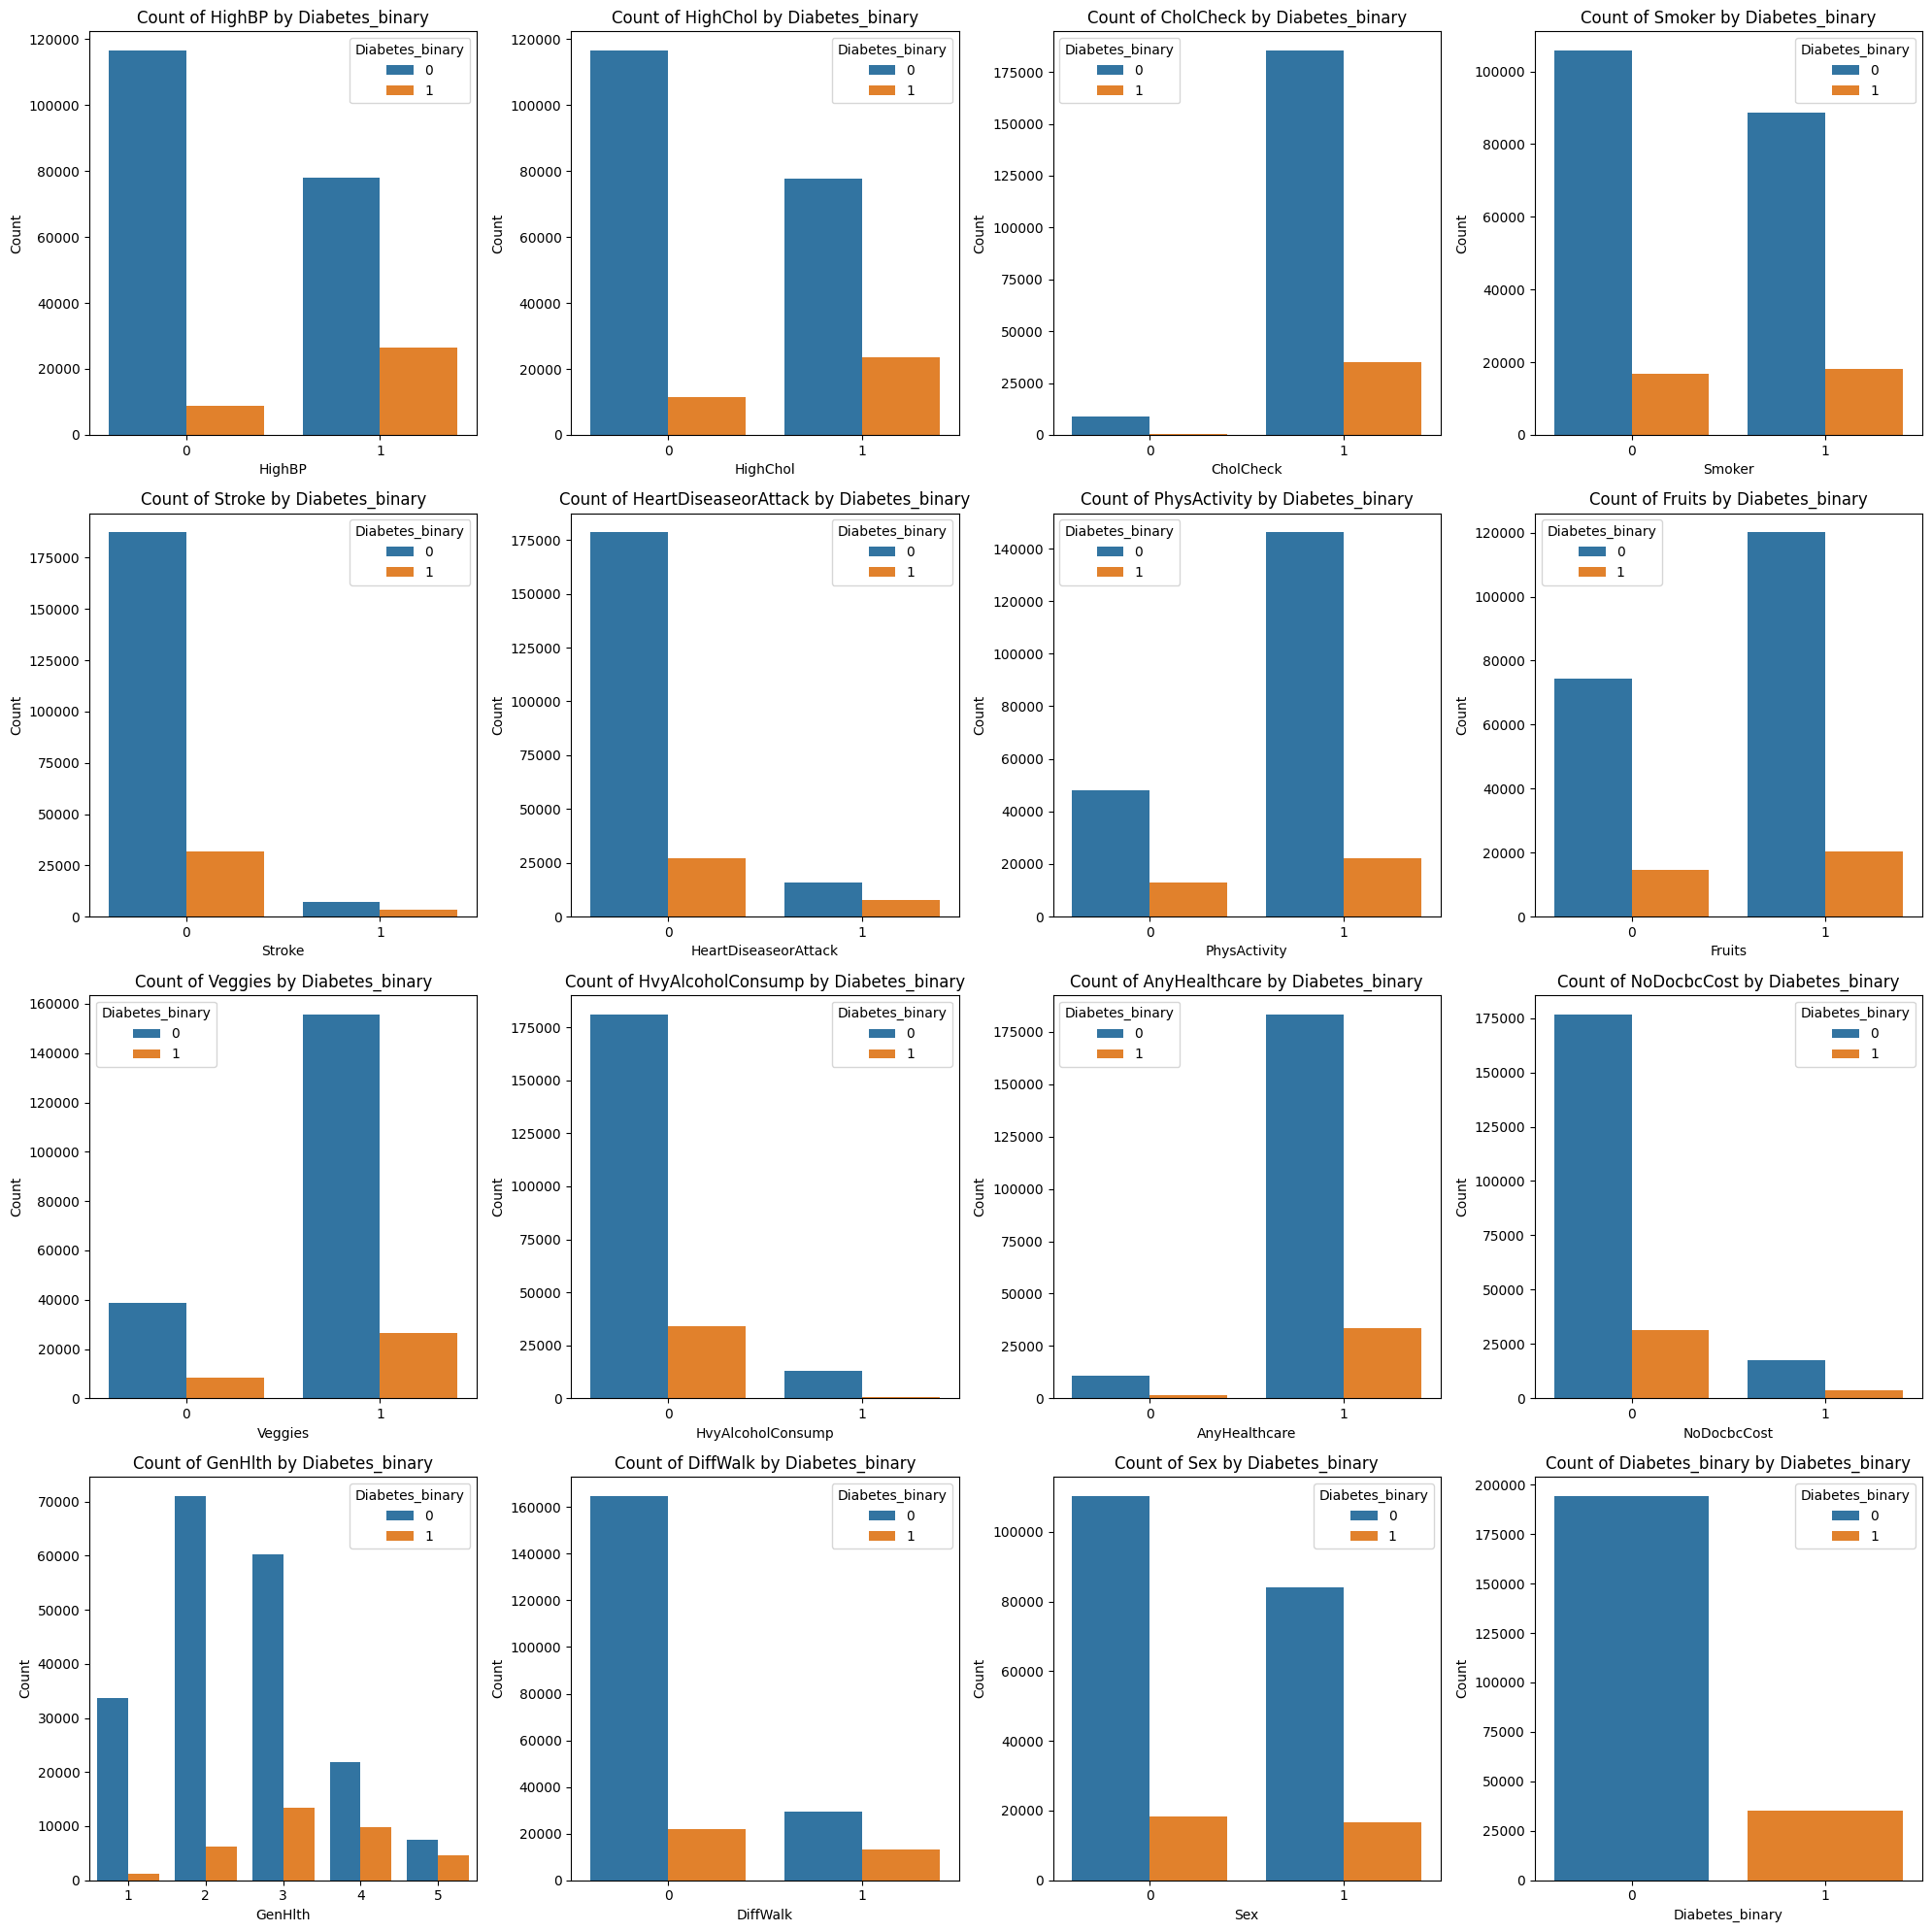

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                     'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                     'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex','Diabetes_binary']

# Box plots for numerical columns by Diabetes_binary
fig, axes = plt.subplots(2, 3, figsize=(15, 8)) # Adjusted to 2 rows and 3 columns for 6 plots
axes = axes.flatten() # Flatten the 2x3 array of axes to easily iterate

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Diabetes_binary', y=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Diabetes_binary')
    axes[i].set_xlabel('Diabetes_binary')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


# Count plots for categorical columns by Diabetes_binary in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(20, 20)) # Changed to 4x4 grid for 16 plots
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Diabetes_binary', ax=axes[i])
    axes[i].set_title(f'Count of {col} by Diabetes_binary')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots (although with 16 plots and 16 axes, there won't be any)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

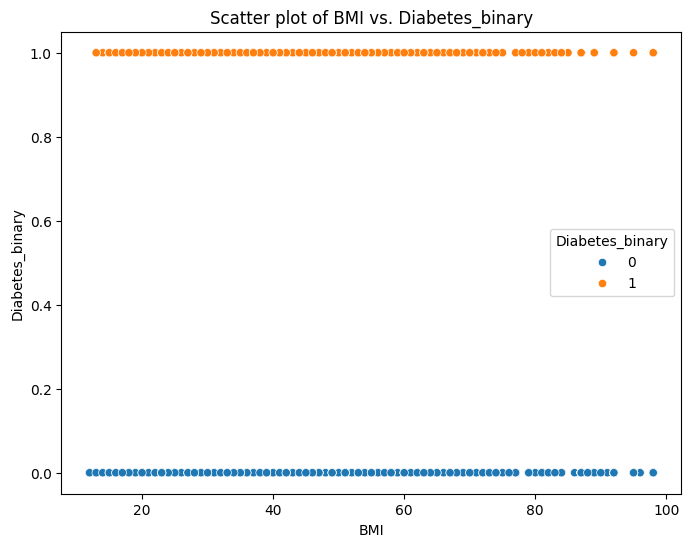

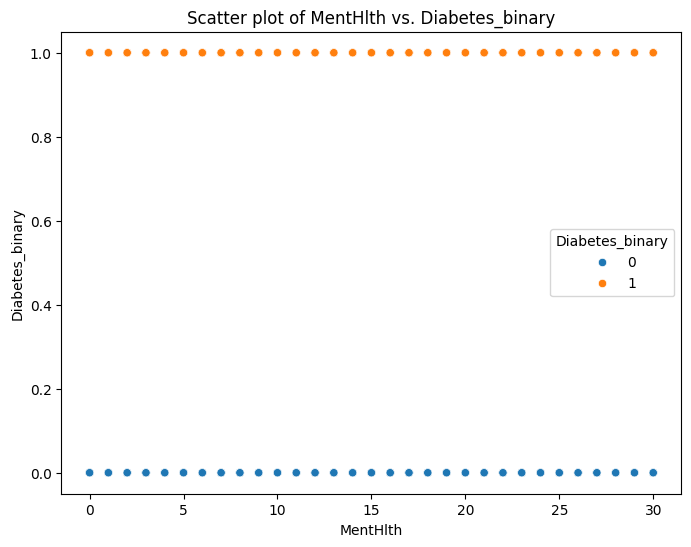

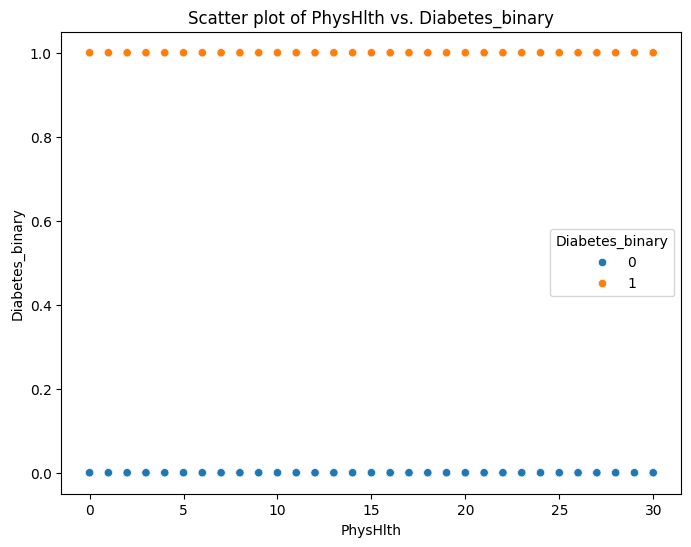

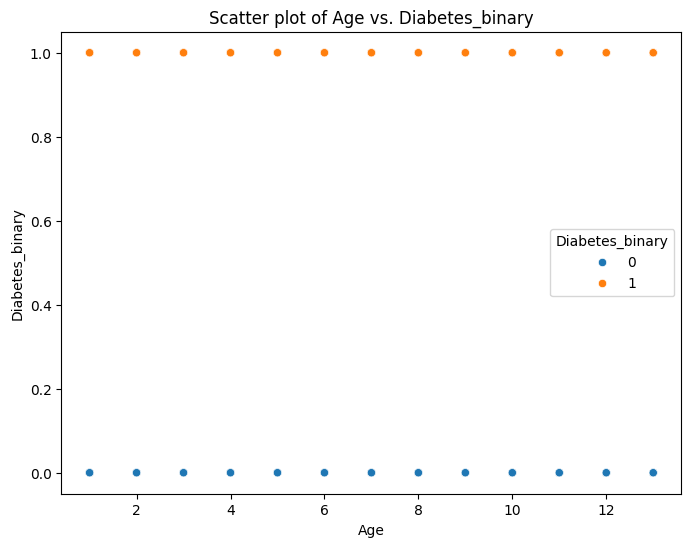

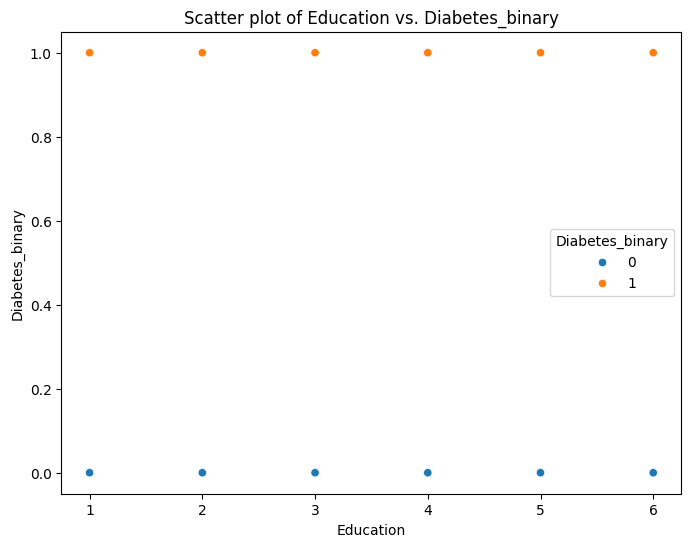

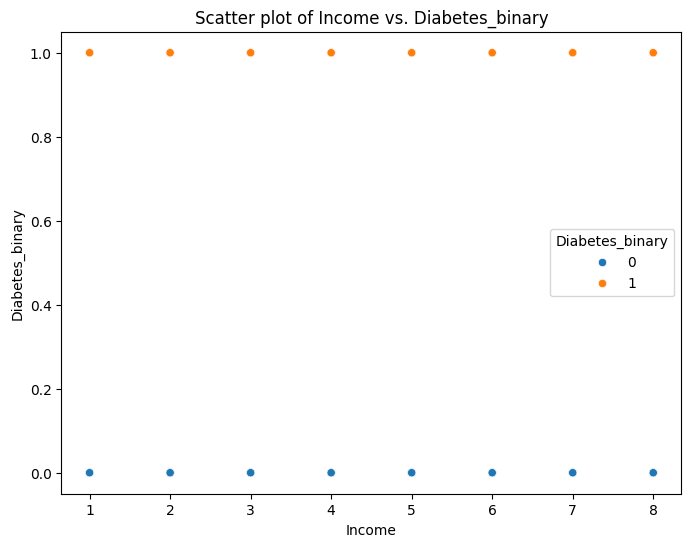

In [18]:
#draw scatter plots for diabetes and other features
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=col, y='Diabetes_binary', hue='Diabetes_binary')
    plt.title(f'Scatter plot of {col} vs. Diabetes_binary')
    plt.xlabel(col)
    plt.ylabel('Diabetes_binary')
    plt.show()

## Perform multivariate analysis

### Subtask:
Use techniques like PCA or t-SNE to reduce dimensionality and visualize the data in lower dimensions to identify potential clusters or patterns.


**Reasoning**:
Import necessary libraries for dimensionality reduction and visualization.



In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

**Reasoning**:
Apply PCA to reduce dimensionality and visualize the results.



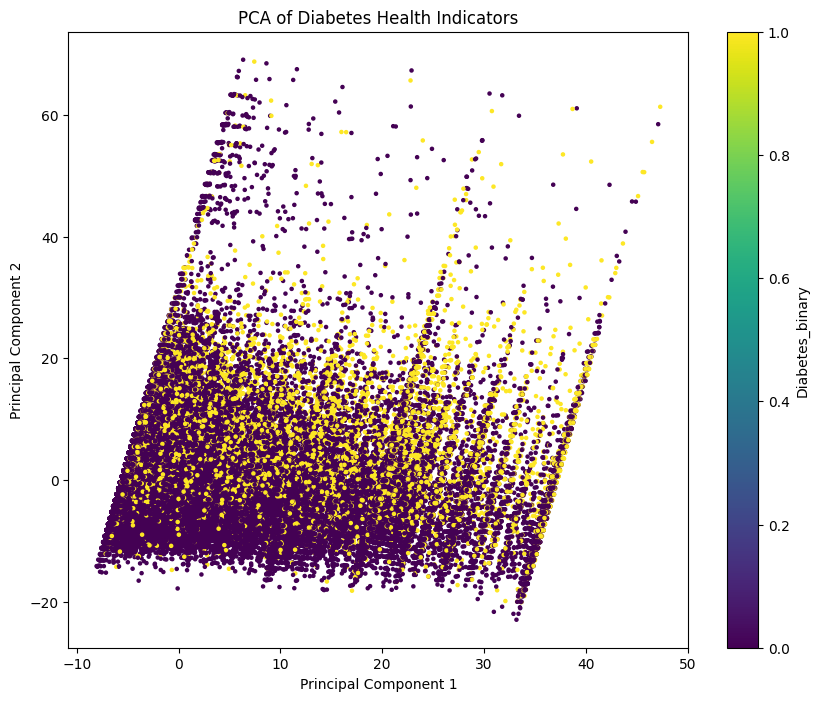

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.values.flatten(), cmap='viridis', s=5)
plt.title('PCA of Diabetes Health Indicators')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Diabetes_binary')
plt.show()

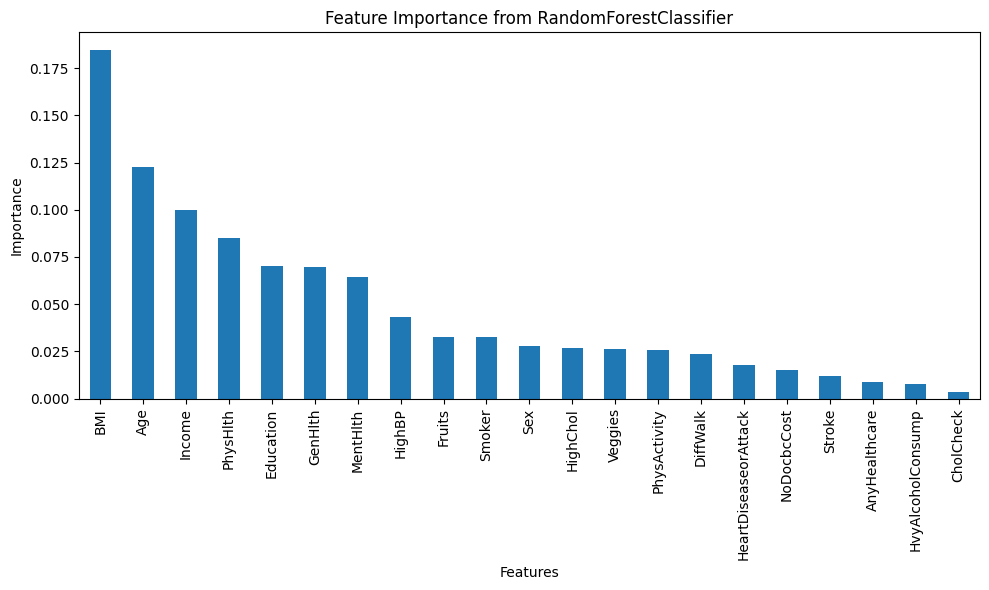

In [21]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Assuming X and y are already loaded and preprocessed
# If not, you would load and preprocess your data here

# Initialize and train a RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y.values.ravel())

# Get feature importances
feature_importances = model.feature_importances_

# Create a pandas Series for easier visualization
feature_importance_series = pd.Series(feature_importances, index=X.columns)

# Sort the features by importance
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Visualize the feature importances
plt.figure(figsize=(10, 6))
sorted_feature_importances.plot(kind='bar')
plt.title('Feature Importance from RandomForestClassifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Task
Prepare the data for model building by separating features and target, handling categorical variables, and splitting the data into training and testing sets.

## Separate features and target

### Subtask:
Separate the features (X) and the target variable (y) from the combined dataframe.


**Reasoning**:
Separate the features (X) and the target variable (y) from the combined dataframe.



In [22]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

## Handle categorical variables

### Subtask:
Encode categorical features, specifically 'Sex', 'Age', 'Education', and 'Income', which are identified as demographic features with integer types representing categories.


**Reasoning**:
Apply one-hot encoding to the specified categorical columns in the features DataFrame X and replace the original columns.



In [23]:
categorical_cols_to_encode = ['Sex', 'Age', 'Education', 'Income']

# Apply one-hot encoding
one_hot_encoded_cols = pd.get_dummies(X[categorical_cols_to_encode], columns=categorical_cols_to_encode, drop_first=True)

# Drop the original categorical columns from X
X = X.drop(categorical_cols_to_encode, axis=1)

# Concatenate the one-hot encoded columns with X
X = pd.concat([X, one_hot_encoded_cols], axis=1)

# Display the first few rows of the updated X to verify
display(X.head())

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,Education_4,Education_5,Education_6,Income_2,Income_3,Income_4,Income_5,Income_6,Income_7,Income_8
0,1,1,1,40,1,0,0,0,0,1,...,True,False,False,False,True,False,False,False,False,False
1,0,0,0,25,1,0,0,1,0,0,...,False,False,True,False,False,False,False,False,False,False
2,1,1,1,28,0,0,0,0,1,0,...,True,False,False,False,False,False,False,False,False,True
3,1,0,1,27,0,0,0,1,1,1,...,False,False,False,False,False,False,False,True,False,False
4,1,1,1,24,0,0,0,1,1,1,...,False,True,False,False,False,True,False,False,False,False


## Split the data

### Subtask:
Split the dataset into training and testing sets.


**Reasoning**:
Split the features and target into training and testing sets.



In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (183579, 42)
Shape of X_test: (45895, 42)
Shape of y_train: (183579,)
Shape of y_test: (45895,)


## Summary:

### Data Analysis Key Findings

*   The features (X) and target variable (y), 'Diabetes\_binary', were successfully separated.
*   Categorical variables 'Sex', 'Age', 'Education', and 'Income' were successfully one-hot encoded.
*   The dataset was split into training and testing sets, with `X_train` having a shape of (183579, 42), `X_test` having a shape of (45895, 42), `y_train` having a shape of (183579,), and `y_test` having a shape of (45895,).

### Insights or Next Steps

*   The data is now prepared for training a machine learning model to predict diabetes based on the provided features.


# Task
Train a classification model using an ensemble method, hyperparameter tuning, StandardScaler, SMOTE, and cross-validation on the provided training data and evaluate it on the testing data.

## Scale the data

### Subtask:
Apply StandardScaler to the training and testing data to standardize the features.


**Reasoning**:
Apply StandardScaler to the training and testing data to standardize the features.



In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (183579, 42)
Shape of X_test_scaled: (45895, 42)


## Handle class imbalance

### Subtask:
Apply SMOTE to the training data to address the class imbalance in the target variable.


**Reasoning**:
Import SMOTE and apply it to the scaled training data to address class imbalance.



In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Shape of original X_train:", X_train_scaled.shape)
print("Shape of resampled X_train:", X_train_resampled.shape)
print("Shape of original y_train:", y_train.shape)
print("Shape of resampled y_train:", y_train_resampled.shape)

Shape of original X_train: (183579, 42)
Shape of resampled X_train: (311128, 42)
Shape of original y_train: (183579,)
Shape of resampled y_train: (311128,)


## Train the model

### Subtask:
Train the model using the scaled and balanced training data with the defined hyperparameter tuning strategy.


**Reasoning**:
Fit the GridSearchCV object to the resampled and scaled training data to perform hyperparameter tuning and cross-validation, then store and print the best estimator and its parameters.



In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report

# --- 1. Model Imports ---
# Linear Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Tree-Based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Instance-Based Model
from sklearn.neighbors import KNeighborsClassifier

# Gradient Boosting Model
# Make sure to install xgboost: pip install xgboost
from xgboost import XGBClassifier




# Split data into training and testing sets

X_train, y_train = X_train_resampled, y_train_resampled


# --- 3. Define All Models and Their Parameter Grids ---
models_and_params = [
    {
        'model': LogisticRegression(max_iter=1000, solver='liblinear'),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l1', 'l2']
        }
    }
    # ,
    # {
    #     'model': SVC(kernel='linear', probability=True),
    #     'params': {
    #         'C': [0.1, 1, 10]
    #     }
    # }
    #,
    # {
    #     'model': DecisionTreeClassifier(),
    #     'params': {
    #         'criterion': ['gini', 'entropy'],
    #         'max_depth': [5, 10, 20],
    #     }
    # },
    # {
    #     'model': KNeighborsClassifier(),
    #     'params': {
    #         'n_neighbors': [3, 5, 9],
    #         'weights': ['uniform', 'distance']
    #     }
    # },
    # {
    #     'model': RandomForestClassifier(),
    #     'params': {
    #         'n_estimators': [100, 200],
    #         'max_depth': [10, 20, None],
    #         'min_samples_leaf': [1, 2]
    #     }
    #  }
    #,
    # {
    #     'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    #     'params': {
    #         'n_estimators': [100, 200],
    #         'learning_rate': [0.05, 0.1],
    #         'max_depth': [3, 5, 7]
    #     }
    # }
]


# --- 4. Run GridSearchCV for Each Model ---
results = []
best_estimator = None
best_accuracy = 0.0

print("Starting comprehensive Grid Search for all 6 models...")

for item in models_and_params:
    model = item['model']
    params = item['params']
    model_name = model.__class__.__name__

    # Using cv=3 to speed up the process for this extensive search
    grid_search = GridSearchCV(estimator=model, param_grid=params, cv=3, n_jobs=-1, scoring='accuracy', verbose=0)
    grid_search.fit(X_train, y_train)

    test_accuracy = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))

    results.append({
        'Model': model_name,
        'Best CV Score': grid_search.best_score_,
        'Test Accuracy': test_accuracy,
        'Best Parameters': grid_search.best_params_
    })

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_estimator = grid_search.best_estimator_

    print(f"Finished for {model_name}.")


# --- 5. Display Results in a Table ---
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', None)

print("\n--- Final Comprehensive Results ---")
print(results_df)


# --- 6. Show Detailed Report for the Best Overall Model ---
print(f"\n--- Best Overall Model: {best_estimator.__class__.__name__} ---")
print(f"Test Accuracy: {best_accuracy:.4f}")
print("\nClassification Report on Test Data:")
y_pred = best_estimator.predict(X_test)
print(classification_report(y_test, y_pred))

Starting comprehensive Grid Search for all 6 models...
Finished for LogisticRegression.

--- Final Comprehensive Results ---
                Model  Best CV Score  Test Accuracy  \
0  LogisticRegression       0.744105       0.154309   

              Best Parameters  
0  {'C': 10, 'penalty': 'l2'}  

--- Best Overall Model: LogisticRegression ---
Test Accuracy: 0.1543

Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     38813
           1       0.15      1.00      0.27      7082

    accuracy                           0.15     45895
   macro avg       0.08      0.50      0.13     45895
weighted avg       0.02      0.15      0.04     45895



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr